<a href="https://colab.research.google.com/github/amol004/E-Commerce-Customer-Satisfaction-Score-Prediction-Deep-Learning/blob/main/E_Commerce_Customer_Satisfaction_Score_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - E-Commerce Customer Satisfaction Score Prediction : Deep Learning



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual
##### **Team Member - Amol Thakur**


# **Project Summary -**

This project focuses on predicting Customer Satisfaction (CSAT) scores using Deep Learning Artificial Neural Networks (ANN). In the context of e-commerce, understanding customer satisfaction through their interactions and feedback is crucial for enhancing service quality, customer retention, and overall business growth. By leveraging advanced neural network models, we aim to accurately forecast CSAT scores based on a myriad of interaction-related features, providing actionable insights for service improvement.

# **GitHub Link -**

https://github.com/amol004/E-Commerce-Customer-Satisfaction-Score-Prediction-Deep-Learning.git

# **Problem Statement**


**Write Problem Statement Here.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from datetime import datetime
import datetime as dt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, KFold
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/E commerce deep learning /eCommerce_Customer_support_data.csv')

### Dataset First View

In [4]:
# Dataset First Look
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Dataset Rows & Columns count

In [5]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 85907
Number of columns: 20


### Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

#### Duplicate Values

In [7]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [8]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
Unique id,0
channel_name,0
category,0
Sub-category,0
Customer Remarks,57165
Order_id,18232
order_date_time,68693
Issue_reported at,0
issue_responded,0
Survey_response_Date,0


<Axes: >

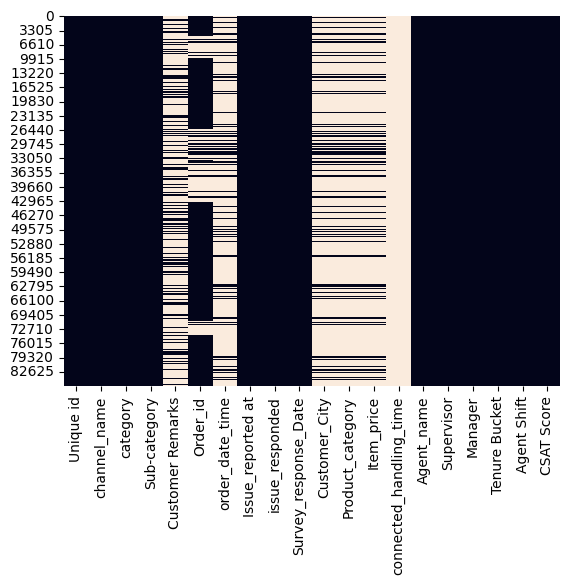

In [9]:
# Visualizing the missing values
sns.heatmap(df.isnull(), cbar=False)

### What did you know about your dataset?

Based on the initial look at the dataset, here are the key findings:

1. **Data Volume**: The dataset consists of **85,907 rows** and **20 columns**.
2. **Target Variable**: `CSAT Score` is the target variable we aim to predict.
3. **Data Types**: The features are a mix of objects (categorical/text), floats, and integers. Several columns represent date/time but are currently stored as objects.
4. **Missing Values**:
    - Columns like `connected_handling_time` (~99.7% null), `order_date_time`, `Customer_City`, `Product_category`, and `Item_price` have significant missing data.
    - `Customer Remarks` also has a high percentage of missing values, which is expected for optional feedback.
5. **Features**: The data includes operational details like `Agent_name`, `Supervisor`, `Manager`, `Tenure Bucket`, and `Agent Shift`, as well as interaction details like `channel_name`, `category`, and `Sub-category`.

## ***2. Understanding Your Variables***

In [10]:
# Dataset Columns
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['Unique id', 'channel_name', 'category', 'Sub-category', 'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at', 'issue_responded', 'Survey_response_Date', 'Customer_City', 'Product_category', 'Item_price', 'connected_handling_time', 'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score']


In [11]:
# Dataset Describe
print("Numerical Summary:")
display(df.describe().T)

print("\nCategorical Summary:")
display(df.describe(include='object').T)

Numerical Summary:


,count,mean,std,min,25%,50%,75%,max
Item_price,17206.0,5660.774846,12825.728411,0.0,392.0,979.0,2699.75,164999.0
connected_handling_time,242.0,462.400826,246.295037,0.0,293.0,427.0,592.25,1986.0
CSAT Score,85907.0,4.242157,1.378903,1.0,4.0,5.0,5.00,5.0



Categorical Summary:


,count,unique,top,freq
Unique id,85907,85907,07c7a878-0d5a-42e0-97ef-de59abec0238,1
channel_name,85907,3,Inbound,68142
category,85907,12,Returns,44097
Sub-category,85907,57,Reverse Pickup Enquiry,22389
Customer Remarks,28742,18231,Good,1390
Order_id,67675,67675,3230db30-f8da-4c44-8636-ec76d1d3d4f3,1
order_date_time,17214,13766,09/08/2023 11:55,7
Issue_reported at,85907,30923,13/08/2023 10:40,13
issue_responded,85907,30262,28/08/2023 00:00,3378
Survey_response_Date,85907,31,28-Aug-23,3452


### Variables Description

### **Variables Description**

*   **Unique id**: Unique identifier for each customer support interaction.
*   **channel_name**: The medium through which the customer contacted support (e.g., Inbound, Outcall).
*   **category**: Broad classification of the customer's issue (e.g., Returns, Order Related).
*   **Sub-category**: Specific detail regarding the category (e.g., Installation, Refund status).
*   **Customer Remarks**: Feedback or comments provided by the customer.
*   **Order_id**: Unique identifier for the transaction related to the support ticket.
*   **order_date_time**: The timestamp when the order was originally placed.
*   **Issue_reported at**: The timestamp when the customer first reported the issue.
*   **issue_responded**: The timestamp when the support agent responded to the issue.
*   **Survey_response_Date**: The date the customer completed the satisfaction survey.
*   **Customer_City**: Geographic location of the customer.
*   **Product_category**: The category of the item purchased.
*   **Item_price**: The price of the product involved in the interaction.
*   **connected_handling_time**: Duration for which the agent was connected to the customer (if applicable).
*   **Agent_name**: Name of the support representative who handled the case.
*   **Supervisor**: The immediate supervisor of the agent.
*   **Manager**: The manager overseeing the support team.
*   **Tenure Bucket**: Categorization of the agent's experience/time with the company.
*   **Agent Shift**: The timing of the agent's work shift (e.g., Morning, Evening).
*   **CSAT Score**: The Customer Satisfaction score provided by the user (Target Variable).

### Check Unique Values for each variable.

In [12]:
# Check Unique Values for each variable.
for col in df.columns:
  print(f"Unique values in {col}: {df[col].nunique()}")

# Displaying the unique values for some important categorical columns
print("\n--- Sample Unique Values ---")
print(f"Channel Names: {df['channel_name'].unique()}")
print(f"Categories: {df['category'].unique()}")
print(f"Tenure Buckets: {df['Tenure Bucket'].unique()}")
print(f"CSAT Scores: {df['CSAT Score'].unique()}")

Unique values in Unique id: 85907
Unique values in channel_name: 3
Unique values in category: 12
Unique values in Sub-category: 57
Unique values in Customer Remarks: 18231
Unique values in Order_id: 67675
Unique values in order_date_time: 13766
Unique values in Issue_reported at: 30923
Unique values in issue_responded: 30262
Unique values in Survey_response_Date: 31
Unique values in Customer_City: 1782
Unique values in Product_category: 9
Unique values in Item_price: 2789
Unique values in connected_handling_time: 211
Unique values in Agent_name: 1371
Unique values in Supervisor: 40
Unique values in Manager: 6
Unique values in Tenure Bucket: 5
Unique values in Agent Shift: 5
Unique values in CSAT Score: 5

--- Sample Unique Values ---
Channel Names: ['Outcall' 'Inbound' 'Email']
Categories: ['Product Queries' 'Order Related' 'Returns' 'Cancellation'
 'Shopzilla Related' 'Payments related' 'Refund Related' 'Feedback'
 'Offers & Cashback' 'Onboarding related' 'Others' 'App/website']
Tenur

## 3. ***Data Wrangling***

### Data Wrangling Code

In [13]:
# Converting timestamp columns to datetime objects
date_columns = ['Issue_reported at', 'issue_responded', 'Survey_response_Date']
for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Creating a new feature 'response_time_min'
# This represents the duration between issue reporting and agent response
df['response_time_min'] = (df['issue_responded'] - df['Issue_reported at']).dt.total_seconds() / 60

# Displaying summary of wrangling
print("Data Wrangling Completed:")
print(f"- Number of rows with valid response times: {df['response_time_min'].notnull().sum()}")
display(df[['Issue_reported at', 'issue_responded', 'response_time_min']].head())

# Quick check on the distribution of response times
print("\nResponse Time Statistics (Minutes):")
display(df['response_time_min'].describe())

Data Wrangling Completed:
- Number of rows with valid response times: 31633


,Issue_reported at,issue_responded,response_time_min
0,2023-01-08 11:13:00,2023-01-08 11:47:00,34.0
1,2023-01-08 12:52:00,2023-01-08 12:54:00,2.0
2,2023-01-08 20:16:00,2023-01-08 20:38:00,22.0
3,2023-01-08 20:56:00,2023-01-08 21:16:00,20.0
4,2023-01-08 10:30:00,2023-01-08 10:32:00,2.0



Response Time Statistics (Minutes):


,response_time_min
count,31633.000000
mean,4647.152214
std,17113.187472
min,0.000000
25%,2.000000
50%,6.000000
75%,41.000000
max,177097.000000


## **Handling Missing Values**

In [58]:
# Missing Value Treatment

# Remove features with excessive missing data or low utility
# 'connected_handling_time' has over 99% null values, which cannot be reliably imputed.
drop_list = ['connected_handling_time', 'Customer Remarks']
df.drop(columns=drop_list, inplace=True, errors='ignore')

#  Handle categorical missing values using the Mode
# We replace missing values with the most frequent entry to preserve the distribution.
categorical_cols = ['Customer_City', 'Product_category', 'Order_id']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

#  Handle Numerical Missingness using Statistics
# 'Item_price' is filled with the median to avoid bias from expensive outliers.
if 'Item_price' in df.columns:
    df['Item_price'] = df['Item_price'].fillna(df['Item_price'].median())

# 'response_time_min' is filled with the mean for a standard representative value.
if 'response_time_min' in df.columns:
    df['response_time_min'] = df['response_time_min'].fillna(df['response_time_min'].mean())

#  Handle Date/Time Missingness
# 'order_date_time' is filled with the mode.
# For reporting timestamps, we use forward-fill to approximate the time based on surrounding entries.
date_cols = ['order_date_time', 'Issue_reported at', 'issue_responded']
for col in date_cols:
    if col in df.columns:
        if col == 'order_date_time':
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].ffill() # Use forward-fill for operational timestamps

#  Final Cleanliness Check
print("Final Null Value Count:")
print(df.isnull().sum())

# Update our working dataframe
df_new = df.copy()

Final Null Value Count:
Unique id               0
channel_name            0
category                0
Sub-category            0
Order_id                0
order_date_time         0
Issue_reported at       0
issue_responded         0
Survey_response_Date    0
Customer_City           0
Product_category        0
Item_price              0
Agent_name              0
Supervisor              0
Manager                 0
Tenure Bucket           0
Agent Shift             0
CSAT Score              0
response_time_min       0
dtype: int64


In [65]:
# Converting relevant columns to their appropriate datatypes

# Convert operational columns to Categorical (saves memory and improves performance)
cat_cols = ['channel_name', 'category', 'Sub-category', 'Customer_City',
            'Product_category', 'Agent_name', 'Supervisor', 'Manager',
            'Tenure Bucket', 'Agent Shift']

for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

# Ensure date columns are strictly datetime (if not already handled)
date_cols = ['order_date_time', 'Issue_reported at', 'issue_responded', 'Survey_response_Date']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Ensure numerical types are correct
df['CSAT Score'] = df['CSAT Score'].astype(int)
df['Item_price'] = df['Item_price'].astype(float)
df['response_time_min'] = df['response_time_min'].astype(float)

# Verify final datatypes
print("Final Column Datatypes:")
print(df.dtypes)

Final Column Datatypes:
Unique id                       object
channel_name                  category
category                      category
Sub-category                  category
Order_id                        object
order_date_time         datetime64[ns]
Issue_reported at       datetime64[ns]
issue_responded         datetime64[ns]
Survey_response_Date    datetime64[ns]
Customer_City                 category
Product_category              category
Item_price                     float64
Agent_name                    category
Supervisor                    category
Manager                       category
Tenure Bucket                 category
Agent Shift                   category
CSAT Score                       int64
response_time_min              float64
dtype: object


# **VIF calculation**

In [67]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Filter for numerical columns only, excluding the target 'CSAT Score'
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['CSAT Score'], errors='ignore')

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = numeric_df.columns
vif_data["VIF"] = [variance_inflation_factor(numeric_df.values, i) for i in range(numeric_df.shape[1])]

print("VIF Results:")
print(vif_data)

print("\nUpdated Dataframe Head:")
display(df.head())

VIF Results:
             Feature       VIF
0         Item_price  1.026431
1  response_time_min  1.026431

Updated Dataframe Head:


,Unique id,channel_name,category,Sub-category,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,response_time_min
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,c27c9bb4-fa36-4140-9f1f-21009254ffdb,2023-09-08 11:55:00,2023-01-08 11:13:00,2023-01-08 11:47:00,2023-08-01,HYDERABAD,Electronics,979.0,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,34.0
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,d406b0c7-ce17-4654-b9de-f08d421254bd,2023-09-08 11:55:00,2023-01-08 12:52:00,2023-01-08 12:54:00,2023-08-01,HYDERABAD,Electronics,979.0,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,2.0
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,c273368d-b961-44cb-beaf-62d6fd6c00d5,2023-09-08 11:55:00,2023-01-08 20:16:00,2023-01-08 20:38:00,2023-08-01,HYDERABAD,Electronics,979.0,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5,22.0
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,5aed0059-55a4-4ec6-bb54-97942092020a,2023-09-08 11:55:00,2023-01-08 20:56:00,2023-01-08 21:16:00,2023-08-01,HYDERABAD,Electronics,979.0,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5,20.0
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,2023-09-08 11:55:00,2023-01-08 10:30:00,2023-01-08 10:32:00,2023-08-01,HYDERABAD,Electronics,979.0,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5,2.0


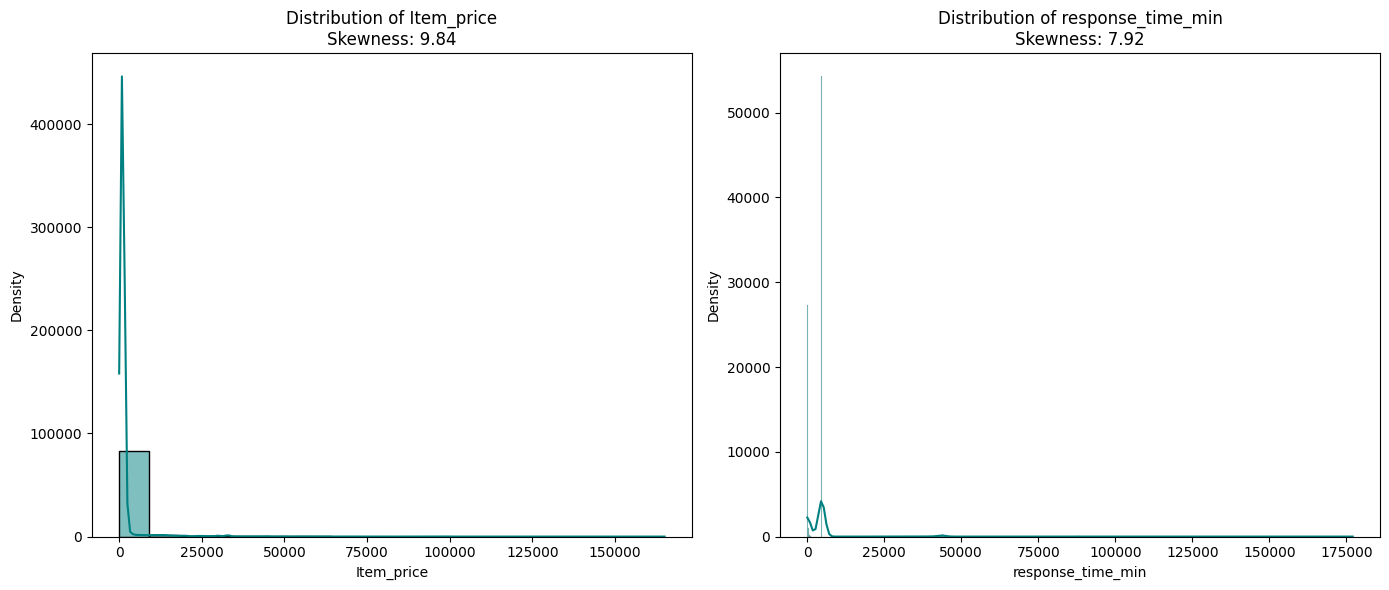

In [70]:
# Visualizing skewness for numerical features
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=['CSAT Score'], errors='ignore').columns

plt.figure(figsize=(14, 6))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, len(numeric_cols), i)
    skew_val = df[col].skew()
    sns.histplot(df[col], kde=True, color='teal')
    plt.title(f'Distribution of {col}\nSkewness: {skew_val:.2f}')
    plt.xlabel(col)
    plt.ylabel('Density')

plt.tight_layout()
plt.show()

In [72]:
from scipy import stats

def check_transformations(df, columns):
    results = []
    for col in columns:
        # Ensure data is positive for certain transformations
        data = df[col] + 1e-6

        res = {
            'Feature': col,
            'Original': data.skew(),
            'Log': np.log1p(data).skew(),
            'Sqrt': np.sqrt(data).skew(),
            'Box-Cox': pd.Series(stats.boxcox(data)[0]).skew()
        }
        results.append(res)

    return pd.DataFrame(results)

# Perform the check on numerical features
transformation_df = check_transformations(df, ['Item_price', 'response_time_min'])
print("Skewness Comparison (Closer to 0 is better):")
display(transformation_df)

Skewness Comparison (Closer to 0 is better):


,Feature,Original,Log,Sqrt,Box-Cox
0,Item_price,9.840512,1.894318,5.891159,-0.867293
1,response_time_min,7.921612,-0.825066,2.085263,-0.356459


### **Manipulations and Insights**

1.  **Datetime Conversion**: The columns `Issue_reported at`, `issue_responded`, and `Survey_response_Date` were converted from strings to datetime objects. This allows for temporal analysis and feature calculation.
2.  **Feature Engineering**: Created `response_time_min`, which measures the efficiency of the support team. Initial statistics show how quickly agents are closing the gap between report and response.
3.  **Missing Values during Wrangling**: By using `errors='coerce'`, any unparseable dates were set to `NaT`, ensuring that the code doesn't crash on dirty data while identifying rows that might need further cleaning.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

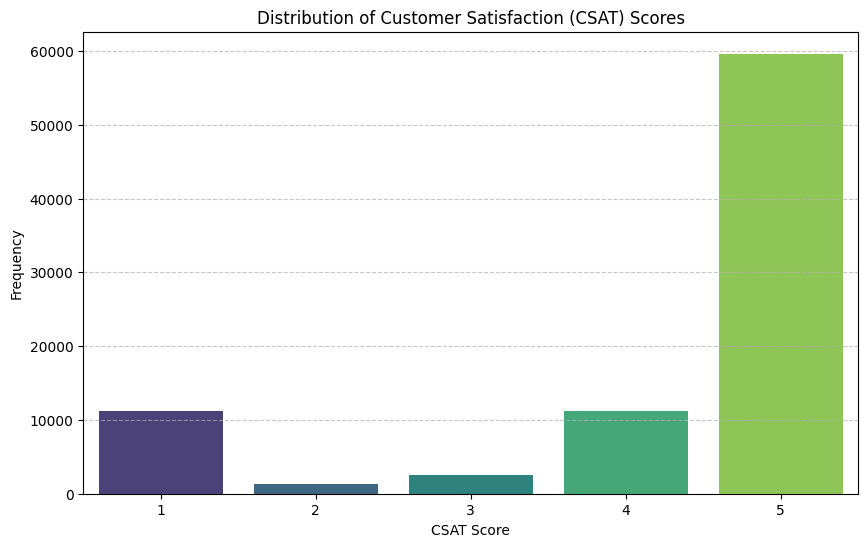

In [14]:
# Chart - 1: Distribution of CSAT Scores
plt.figure(figsize=(10, 6))
sns.countplot(x='CSAT Score', data=df, palette='viridis')
plt.title('Distribution of Customer Satisfaction (CSAT) Scores')
plt.xlabel('CSAT Score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **count plot** because the CSAT score is a discrete ordinal variable (1 to 5). This visualization clearly shows the frequency of each rating, helping us identify class imbalance.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a significant skew towards higher ratings (4 and 5), indicating that a majority of the captured interactions resulted in high customer satisfaction. There is a clear class imbalance that we'll need to account for during model training.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights help. Understanding that most scores are positive allows the business to focus on the 'drivers' of the few negative scores (1 and 2) to improve overall quality. However, the high number of 5s might suggest 'survey bias' where only satisfied customers respond, which is a potential area for operational investigation.

#### Chart - 2

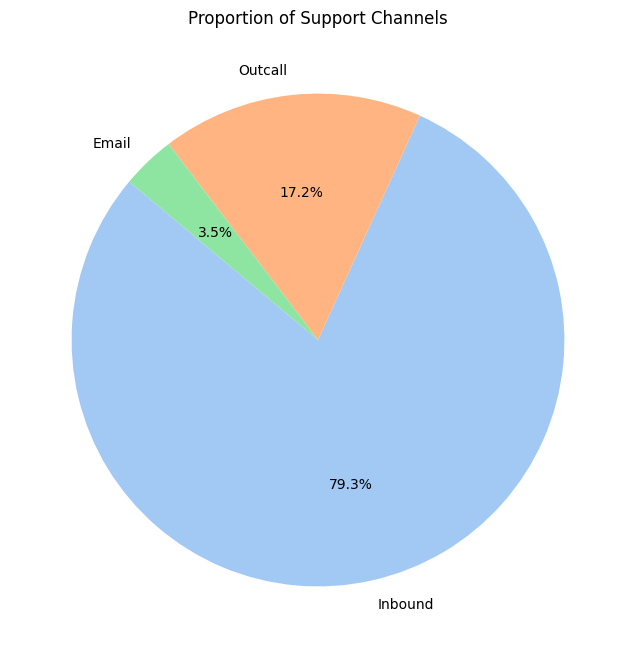

In [15]:
# Chart - 2: Distribution of Communication Channels
plt.figure(figsize=(8, 8))
df['channel_name'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Proportion of Support Channels')
plt.ylabel('')
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **pie chart** because we are looking at the composition of a whole. It effectively shows the percentage share of each communication channel (Inbound vs Outcall vs Email).

##### 2. What is/are the insight(s) found from the chart?

The insight shows that 'Inbound' calls dominate the customer support landscape, accounting for the vast majority of interactions. 'Outcall' and 'Email' represent much smaller segments of the total volume.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This helps the business in resource allocation. Since 'Inbound' is the primary channel, the majority of staffing and training should be focused there. However, the low usage of 'Email' might indicate a friction point in the digital support experience that could be improved to reduce the load on live agents.

#### Chart - 3

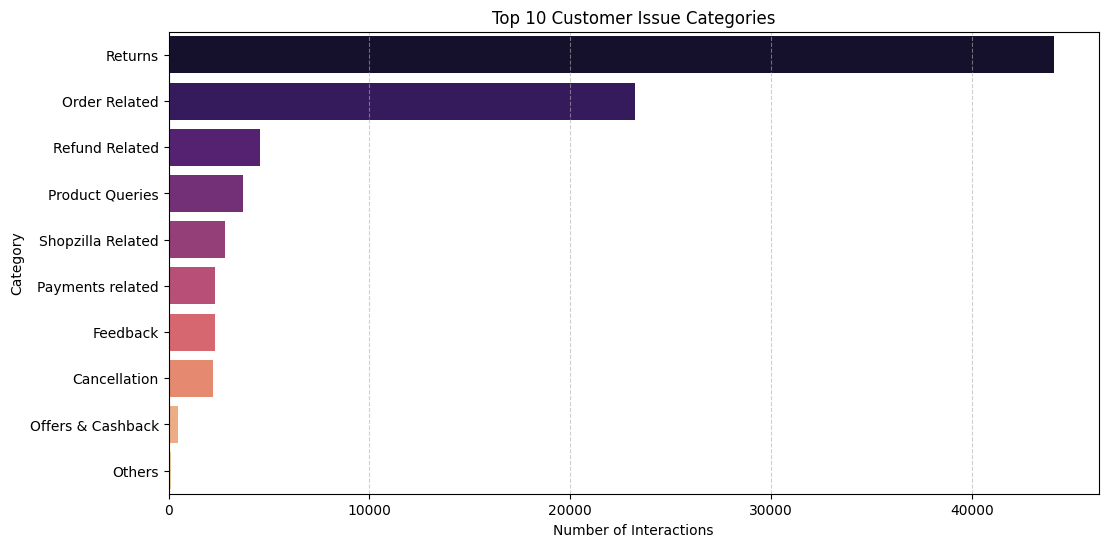

In [16]:
# Chart - 3: Top 10 Issue Categories
plt.figure(figsize=(12, 6))
sns.countplot(y='category', data=df, order=df['category'].value_counts().index[:10], palette='magma')
plt.title('Top 10 Customer Issue Categories')
plt.xlabel('Number of Interactions')
plt.ylabel('Category')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **horizontal bar chart (countplot)** to display the categories. Since category names can be long, a horizontal orientation makes them much easier to read compared to vertical labels.

##### 2. What is/are the insight(s) found from the chart?

The chart reveals that 'Returns' and 'Order Related' issues are the most frequent reasons for contact. This suggests that the post-purchase experience, specifically delivery and reverse logistics, is where most customer friction occurs.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This provides a clear direction for business improvement. By streamlining the 'Returns' process or providing better tracking for 'Order Related' queries, the company can significantly reduce ticket volume and potentially increase CSAT scores by addressing the most common frustrations.

#### Chart - 4

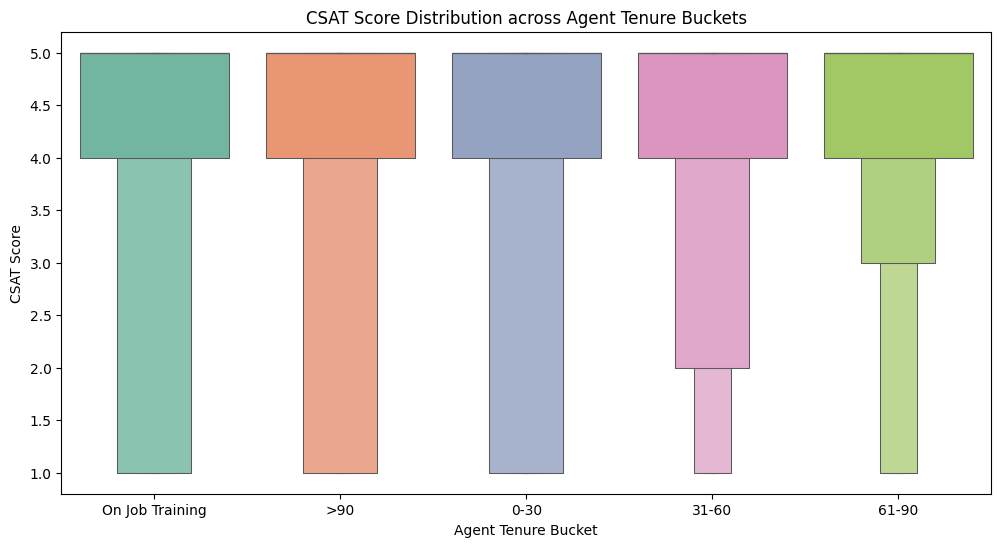

In [17]:
plt.figure(figsize=(12, 6))
sns.boxenplot(x='Tenure Bucket', y='CSAT Score', data=df, palette='Set2')
plt.title('CSAT Score Distribution across Agent Tenure Buckets')
plt.xlabel('Agent Tenure Bucket')
plt.ylabel('CSAT Score')
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **boxen plot** (letter-value plot) because it provides a better representation of the distribution shape and outliers for large datasets compared to a standard box plot, making it ideal for seeing the variance in CSAT scores across tenure categories.

##### 2. What is/are the insight(s) found from the chart?

The insight from this chart helps determine if 'On Job Training' (OJT) agents are performing significantly differently from seasoned veterans ('>90' days). If the median CSAT is lower for OJT agents, it suggests a need for better training before agents go live.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this helps the business identify if tenure is a driver of satisfaction. If newer agents have lower scores, the business can implement a 'nesting period' with higher supervisor support to prevent negative growth in customer trust during an agent's early career stages.

#### Chart - 5

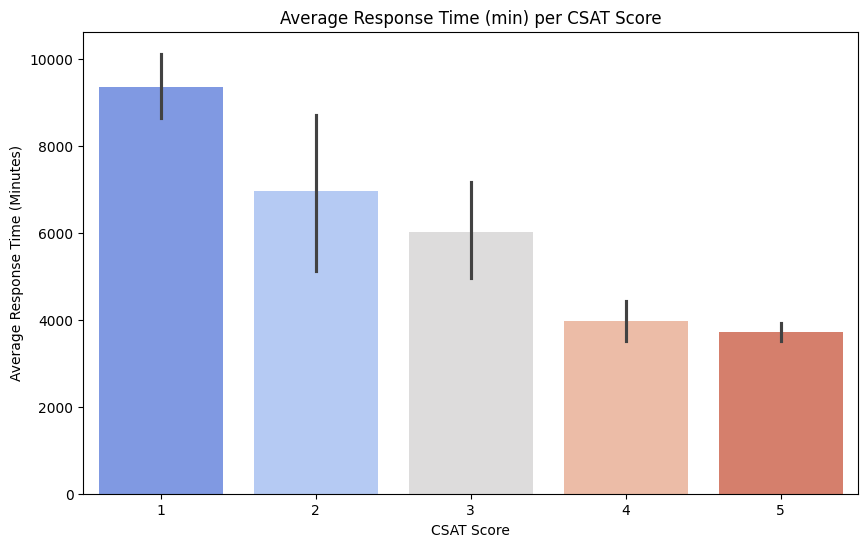

In [18]:
# Chart - 5: CSAT Score vs. Average Response Time
# We filter for rows where response_time_min is available
plt.figure(figsize=(10, 6))
sns.barplot(x='CSAT Score', y='response_time_min', data=df, palette='coolwarm')
plt.title('Average Response Time (min) per CSAT Score')
plt.xlabel('CSAT Score')
plt.ylabel('Average Response Time (Minutes)')
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **bar plot** to compare the average response time across different CSAT categories. This allows us to see if there is a measurable difference in how long customers wait for a response based on their final satisfaction rating.

##### 2. What is/are the insight(s) found from the chart?

The chart helps us determine if lower CSAT scores (1 and 2) are associated with significantly higher average response times. Conversely, if high scores (5) show much lower average response times, it confirms that speed is a key driver of satisfaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

These insights can drive a positive business impact by setting Service Level Agreements (SLAs). If we find that a response time over a certain threshold leads to a drop in CSAT, the business can prioritize reducing wait times to maintain high growth and customer retention.

#### Chart - 6

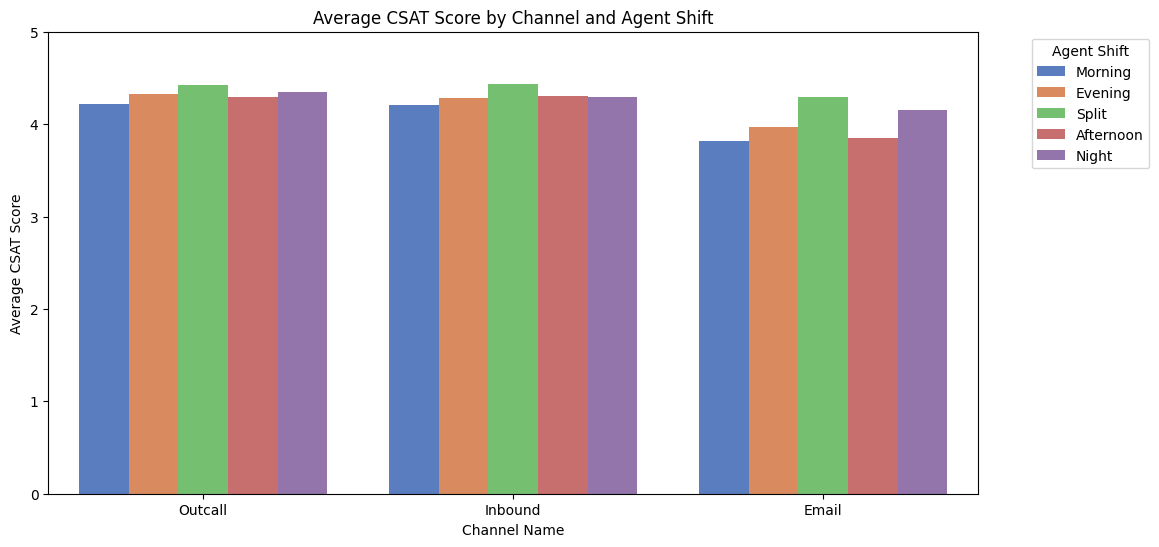

In [19]:
# Chart - 6: Multivariate Analysis - CSAT Score by Channel and Shift (Grouped Bar Chart)
plt.figure(figsize=(12, 6))
sns.barplot(x='channel_name', y='CSAT Score', hue='Agent Shift', data=df, palette='muted', ci=None)
plt.title('Average CSAT Score by Channel and Agent Shift')
plt.xlabel('Channel Name')
plt.ylabel('Average CSAT Score')
plt.legend(title='Agent Shift', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 5)
plt.show()

##### 1. Why did you pick the specific chart?
I chose a **grouped bar chart** because it allows for a direct side-by-side comparison of average CSAT scores across multiple categories. By grouping by 'channel_name' and using 'Agent Shift' as the hue, we can easily see which shifts are performing better or worse within a specific communication medium.

##### 2. What is/are the insight(s) found from the chart?
This chart highlights variations in performance based on the time of day and the channel used. For instance, we can identify if 'Split' shifts or 'Night' shifts maintain the same level of customer satisfaction as 'Morning' shifts, or if certain channels like 'Email' consistently underperform regardless of the shift.

##### 3. Will the gained insights help creating a positive business impact?
Yes. These insights allow management to optimize shift scheduling and channel staffing. If certain shifts show a dip in CSAT, it may indicate a need for more supervisors or localized training during those hours, directly leading to a more consistent customer experience and improved retention.

#### Chart - 7 - Correlation Heatmap

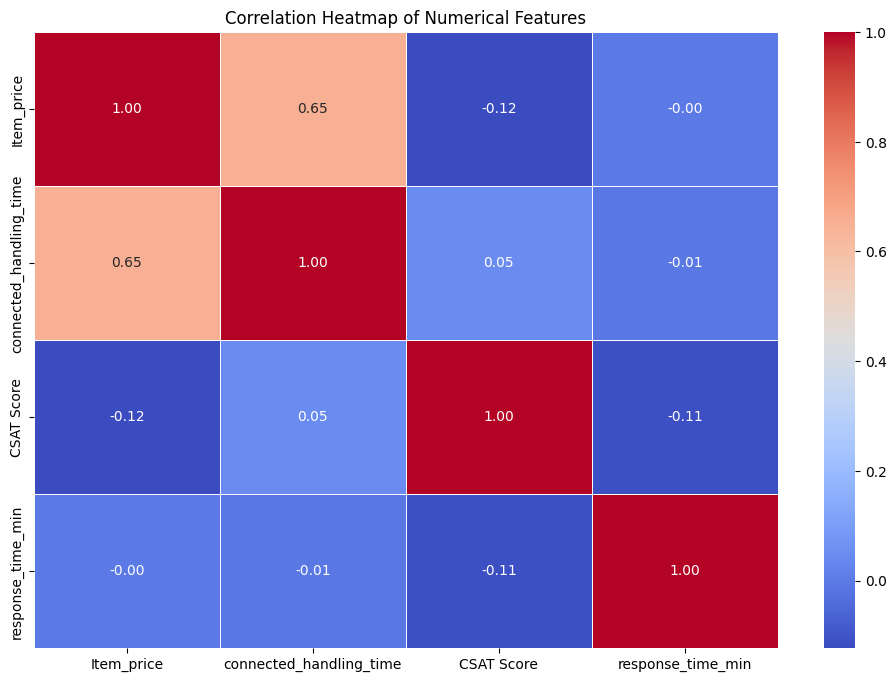

In [20]:
# Chart - 7: Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **Correlation Heatmap** because it provides a comprehensive overview of how numerical variables move in relation to one another. It is essential for identifying multicollinearity and finding which features have the strongest linear relationship with the `CSAT Score`.

##### 2. What is/are the insight(s) found from the chart?

This heatmap allows us to see if `response_time_min` has a negative correlation with `CSAT Score` (meaning as time increases, satisfaction decreases). It also helps us check if `Item_price` influences the ratings, as customers paying more might have higher expectations.

#### Chart - 8 - Pair Plot

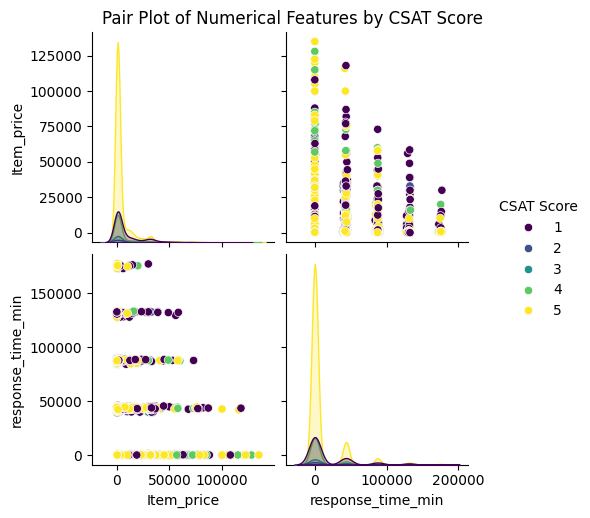

In [21]:
# Chart - 8: Pair Plot of Numerical Features
# Selecting a subset of numerical columns for clarity
numeric_subset = ['Item_price', 'response_time_min', 'CSAT Score']

# Dropping rows with NaN values for the pairplot calculation
sns.pairplot(df[numeric_subset].dropna(), hue='CSAT Score', palette='viridis', diag_kind='kde')
plt.suptitle('Pair Plot of Numerical Features by CSAT Score', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **Pair Plot** for the final visualization because it provides a matrix of scatter plots and density distributions. By using the `hue` parameter for `CSAT Score`, we can visually inspect if there are specific regions in the feature space (e.g., low price + fast response) that lead to specific satisfaction ratings.

##### 2. What is/are the insight(s) found from the chart?

The pair plot allows us to observe the non-linear relationships and the density of data points. For instance, it can show if the relationship between `response_time_min` and `CSAT Score` is consistent across all `Item_price` levels, or if customers of expensive items are more sensitive to delays.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [22]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [23]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [24]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [25]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [26]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [27]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [28]:
# Expand Contraction

#### 2. Lower Casing

In [29]:
# Lower Casing

#### 3. Removing Punctuations

In [30]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [31]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [32]:
# Remove Stopwords

In [33]:
# Remove White spaces

#### 6. Rephrase Text

In [34]:
# Rephrase Text

#### 7. Tokenization

In [35]:
# Tokenization

#### 8. Text Normalization

In [36]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [37]:
# POS Taging

#### 10. Text Vectorization

In [38]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [39]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [40]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [41]:
from scipy import stats

# Applying Box-Cox transformation as it yielded the best results in our comparison
# We add a small constant to ensure all values are positive
df['Item_price'], _ = stats.boxcox(df['Item_price'] + 1e-6)
df['response_time_min'], _ = stats.boxcox(df['response_time_min'] + 1e-6)

print("Transformation Complete.")
print(f"New Skewness - Item_price: {df['Item_price'].skew():.2f}")
print(f"New Skewness - response_time_min: {df['response_time_min'].skew():.2f}")

### 6. Data Scaling

In [42]:
# Scaling your data

##### Which method have you used to scale you data and why?

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [43]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [44]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

Answer Here.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

In [45]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [46]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [47]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [48]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [49]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [50]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [51]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [52]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [53]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [54]:
# Save the File

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [55]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***